# Preamble

In [1]:
!date

Tue Apr  1 13:51:17 PDT 2025


In [2]:
%load_ext autoreload
%load_ext line_profiler

In [3]:
import logging

logging.basicConfig(level=logging.INFO, force=True)

In [4]:
import os as _os

_os.chdir(_os.environ["PROJECT_ROOT"])

In [5]:
import os
from contextlib import contextmanager
from itertools import chain, product
from multiprocessing import Pool

import fastcluster
import graph_tool as gt
import graph_tool.draw
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
import strainzip as sz
import strainzip.app.unzip
import xarray as xr
from graph_tool.util import find_edge
from scipy.cluster.hierarchy import fcluster, linkage
from strainzip.pandas_util import idxwhere
from tqdm import tqdm

import lib.plot

# Params

## Plotting

In [6]:
mpl.rcParams["figure.dpi"] = 100
# sns.set_context('talk')

In [7]:
# Plotting parameters

length_bins = np.logspace(0, 6.5, num=51)
depth_bins = np.logspace(-1, 4, num=51)

linestyle_palette = {"megahit": "--", "strainzip": "-"}
facecolor_palette = {"megahit": "none", "strainzip": "auto"}

draw_graphs = True

## Project params

In [8]:
k = 111
group = "ecoli_mixture1_cov10000"  # "xjin_test6"  # "btheta_mixture1_cov10000"  # "btheta_mixture1_cov1000"
graph_type = f"k{k}-withmegahit3-droptips"
smoothing = "smoothed-6"
deconv = "norm-nobal-nocull-10-10"
marker_model_list = ["TIGR00952_1", "TIGR01063_1", "TIGR02013_1"]

In [9]:
# benchmark = "all_ref_tiles-k5000-o3000"
# benchmark = "all_ref_tiles-k10000-o5000"
# benchmark = "all_ref_tiles-k50000-o30000"
benchmark = "all_ref_cds"

coverage_thresh = 1.0

In [10]:
thresh_list = [
    ("0_identical", 1.0, coverage_thresh),
    ("1_veryhigh", 0.999, coverage_thresh),
    ("2_high", 0.995, coverage_thresh),
    ("3_medium", 0.99, coverage_thresh),
    ("4_verylow", 0.98, coverage_thresh),
]

# Load Data

## Load Metadata

In [11]:
mgen_group = (
    pd.read_table("meta/mgen_group.tsv")[lambda x: x.mgen_group == group]
    .assign(community_id=lambda x: x.mgen_id.str.split("_simcom_").str[0])
    .set_index("mgen_id")
)


mgen_group

,mgen_group,community_id
mgen_id,,
ecoli_mg1655_simcom_len150_seed0_cov10000,ecoli_mixture1_cov10000,ecoli_mg1655
ecoli_o121h19_simcom_len150_seed0_cov10000,ecoli_mixture1_cov10000,ecoli_o121h19
ecoli_0157h7_simcom_len150_seed0_cov10000,ecoli_mixture1_cov10000,ecoli_0157h7
ecoli_14ec020_simcom_len150_seed0_cov10000,ecoli_mixture1_cov10000,ecoli_14ec020
ecoli_atcc11775_simcom_len150_seed0_cov10000,ecoli_mixture1_cov10000,ecoli_atcc11775
ecoli_mg1655_dominated60_simcom_len150_seed1_cov10000,ecoli_mixture1_cov10000,ecoli_mg1655_dominated60
ecoli_o121h19_dominated60_simcom_len150_seed2_cov10000,ecoli_mixture1_cov10000,ecoli_o121h19_dominated60
ecoli_0157h7_dominated60_simcom_len150_seed3_cov10000,ecoli_mixture1_cov10000,ecoli_0157h7_dominated60
ecoli_14ec020_dominated60_simcom_len150_seed4_cov10000,ecoli_mixture1_cov10000,ecoli_14ec020_dominated60


In [12]:
# Build up the sample palette to generalize it across the multiple use cases of this notebook.

sample_palette = lib.plot.construct_ordered_palette(
    [
        "btheta_strainA_simcom_len150_seed0_cov1000",
        "btheta_mixture_75_25_simcom_len150_seed3_cov1000",
        "btheta_mixture_50_50_simcom_len150_seed1_cov1000",
        "btheta_mixture_25_75_simcom_len150_seed2_cov1000",
        "btheta_strainB_simcom_len150_seed0_cov1000",
    ],
    cm="coolwarm",
)
sample_palette = lib.plot.construct_ordered_palette(
    [
        "btheta_strainA_simcom_len150_seed0_cov10000",
        "btheta_mixture_75_25_simcom_len150_seed3_cov10000",
        "btheta_mixture_50_50_simcom_len150_seed1_cov10000",
        "btheta_mixture_25_75_simcom_len150_seed2_cov10000",
        "btheta_strainB_simcom_len150_seed0_cov10000",
    ],
    cm="coolwarm",
    extend=sample_palette,
)

sample_palette = lib.plot.construct_ordered_palette(
    mgen_group.index, extend=sample_palette, cm="coolwarm",
)

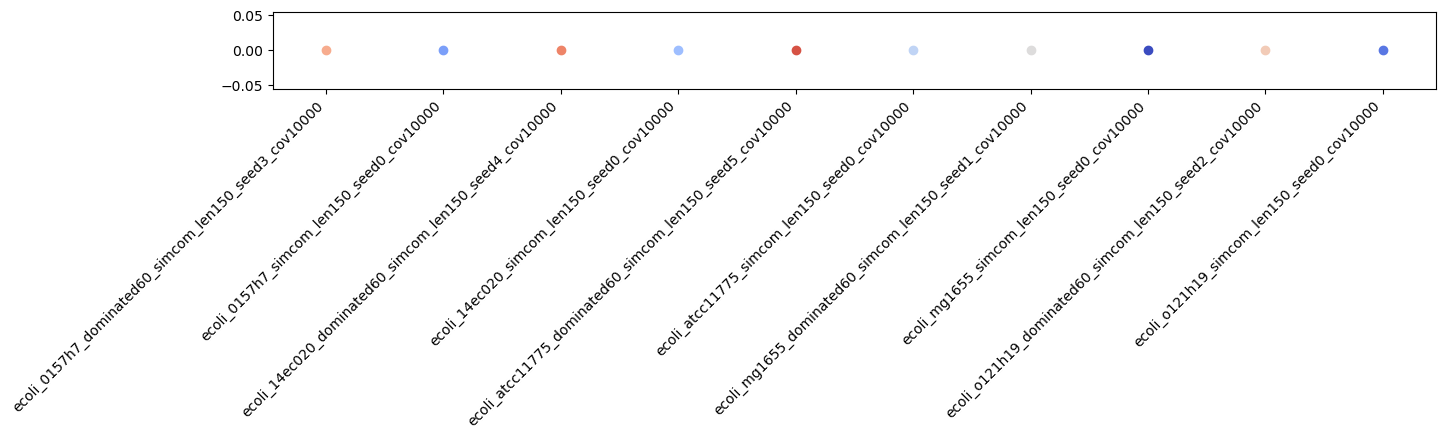

In [13]:
# Build up the sample palette to generalize it across the multiple use cases of this notebook.

fig = plt.figure(figsize=(15, 1))
d = mgen_group.index.to_series().sort_values().map(sample_palette)#.rename('c').reset_index().assign(y=np.arange(len(mgen_group))).set_index('mgen_id')
for i, (m, c) in enumerate(d.items()):
    plt.scatter(i, 0, color=c)
plt.xticks(np.arange(len(d)), d.index)
lib.plot.rotate_xticklabels()

In [14]:
genome_details = pd.read_table("meta/genome_group.tsv")[
    lambda x: x.genome_group_id == group
].assign(
    strain_id=lambda x: x.genome_id.str.rsplit("_").str[0],
)
genome_to_strain = genome_details.set_index("genome_id").strain_id
strain_to_genome = genome_details.set_index("strain_id").genome_id

In [15]:
if group.startswith("xjin"):
    kraken_read_counts = (
        pd.read_csv(
            "/pollard/home/xiaofanj/microbiomeAdhesion/intermediates/biofilmBeadExpV2/customKrakenOutputs/customKraken2BrackenAbundances.csv"
        )
        .set_index(["Strain_Name", "sample"])
        .new_est_reads.unstack("Strain_Name", fill_value=0)
        .rename(index=lambda x: "xjin_" + x)
    )
    known_rabund = kraken_read_counts.rename(columns=strain_to_genome).divide(
        kraken_read_counts.sum(1), axis=0
    )
elif group.startswith("btheta_mixture1") or group.startswith("ecoli_mixture1"):
    sim_fractions = (
        pd.read_table("meta/simulated_community.tsv")[
            lambda x: x.community_id.isin(mgen_group.community_id)
        ]
        .set_index(["community_id", "genome_id"])
        .fraction.unstack(fill_value=0)
    )
    known_rabund = (
        mgen_group[["community_id"]]
        .join(sim_fractions, on="community_id")
        .drop(columns=["community_id"])
        .rename_axis(index="sample")
    )
else:
    assert False, "FIXME: This group type doesn't have a known_rabund..."

assert np.allclose(known_rabund.sum(1), 1)
known_rabund

,ecoli_0157h7,ecoli_14ec020,ecoli_atcc11775,ecoli_mg1655,ecoli_o121h19
sample,,,,,
ecoli_mg1655_simcom_len150_seed0_cov10000,0.0,0.0,0.0,1.0,0.0
ecoli_o121h19_simcom_len150_seed0_cov10000,0.0,0.0,0.0,0.0,1.0
ecoli_0157h7_simcom_len150_seed0_cov10000,1.0,0.0,0.0,0.0,0.0
ecoli_14ec020_simcom_len150_seed0_cov10000,0.0,1.0,0.0,0.0,0.0
ecoli_atcc11775_simcom_len150_seed0_cov10000,0.0,0.0,1.0,0.0,0.0
ecoli_mg1655_dominated60_simcom_len150_seed1_cov10000,0.1,0.1,0.1,0.6,0.1
ecoli_o121h19_dominated60_simcom_len150_seed2_cov10000,0.1,0.1,0.1,0.1,0.6
ecoli_0157h7_dominated60_simcom_len150_seed3_cov10000,0.6,0.1,0.1,0.1,0.1
ecoli_14ec020_dominated60_simcom_len150_seed4_cov10000,0.1,0.6,0.1,0.1,0.1


## Depth

### StrainZip

In [16]:
final_graph = sz.io.load_graph(
    f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.sz"
)

vertex_depth = (
    sz.results.depth_table(final_graph, final_graph.get_vertices())
    .T.rename_axis(index="vertex", columns="sample")
    .rename(columns=mgen_group.index.to_series().reset_index(drop=True))
)
vertex_depth

sample,ecoli_mg1655_simcom_len150_seed0_cov10000,ecoli_o121h19_simcom_len150_seed0_cov10000,ecoli_0157h7_simcom_len150_seed0_cov10000,ecoli_14ec020_simcom_len150_seed0_cov10000,ecoli_atcc11775_simcom_len150_seed0_cov10000,ecoli_mg1655_dominated60_simcom_len150_seed1_cov10000,ecoli_o121h19_dominated60_simcom_len150_seed2_cov10000,ecoli_0157h7_dominated60_simcom_len150_seed3_cov10000,ecoli_14ec020_dominated60_simcom_len150_seed4_cov10000,ecoli_atcc11775_dominated60_simcom_len150_seed5_cov10000
vertex,,,,,,,,,,
0,20.716807,0.034703,21.481828,0.019689,0.019689,12.224176,4.232828,13.999482,3.385504,3.707762
1,21.153517,20.009821,20.321959,22.158238,22.158238,21.139248,23.417074,20.893327,21.246698,21.326475
2,20.949642,22.086342,20.291077,20.530294,20.530294,20.635321,21.413807,19.556394,22.311493,21.861561
3,0.047294,0.107919,22.641047,0.021375,0.021375,1.943545,2.184843,12.682228,1.723205,2.350946
4,20.985936,22.318262,21.563055,20.750398,20.750398,21.630973,20.221891,21.274279,21.840917,20.462541
...,...,...,...,...,...,...,...,...,...,...
50628,21.464292,0.000676,0.002208,0.003255,0.003255,12.352867,1.668406,2.095666,1.240287,1.948599
50629,0.000506,21.507203,0.001110,0.000475,0.000475,0.594896,12.278246,1.998925,1.716208,2.063542
50630,0.000453,20.925549,0.003237,0.000739,0.000739,2.291568,11.687427,2.094649,1.886280,1.969639


### MEGAHIT/Bowtie2

In [17]:
megahit_gene_depth = pd.read_table(
    f"data/group/{group}/r.proc.megahit-full-k111.prodigal.gene_depth.tsv",
    names=["sample", "gene", "depth"],
    index_col=["sample", "gene"],
).depth.unstack("sample", fill_value=0)

In [18]:
megahit_contig_depth = pd.read_table(
    f"data/group/{group}/r.proc.megahit-full-k111.contig_depth.tsv",
    names=["sample", "contig", "depth"],
    index_col=["sample", "contig"],
).depth.unstack("sample", fill_value=0)

## Genes

### StrainZip

In [19]:
strainzip_gene = pd.read_table(
    f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.prodigal.bed",
    names=["vertex", "left", "right", "gene", "score", "strand"],
)
strainzip_gene

,vertex,left,right,gene,score,strand
0,0,0,192,0[0-192]+,0,+
1,1,2,131,1[2-131]+,0,+
2,10,1,172,10[1-172]+,0,+
3,100,0,123,100[0-123]+,0,+
4,1000,0,258,1000[0-258]+,0,+
...,...,...,...,...,...,...
100734,9993,2,119,9993[2-119]-,0,-
100735,9994,1,280,9994[1-280]+,0,+
100736,9995,0,285,9995[0-285]+,0,+
100737,9998,2,227,9998[2-227]-,0,-


#### Depth Markers

In [20]:
total_strainzip_marker_depth = {}

for marker_model in marker_model_list:
    strainzip_marker_gene_list = pd.read_table(
        f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.cds.tran.hmmer-{marker_model}-ga.tsv",
        names=["gene", "gene_name", "bitscore"],
    ).gene.tolist()

    # print(strainzip_marker_gene_list)

    total_strainzip_marker_depth[marker_model] = vertex_depth.loc[
        strainzip_gene[lambda x: x.gene.isin(strainzip_marker_gene_list)].vertex
    ].sum()

total_strainzip_marker_depth = pd.DataFrame(total_strainzip_marker_depth)
print(total_strainzip_marker_depth)

total_strainzip_marker_depth = total_strainzip_marker_depth.mean(1)
print(total_strainzip_marker_depth)

                                                    TIGR00952_1  TIGR01063_1  \
sample                                                                         
ecoli_mg1655_simcom_len150_seed0_cov10000             42.522273    44.559386   
ecoli_o121h19_simcom_len150_seed0_cov10000            42.720837    20.507948   
ecoli_0157h7_simcom_len150_seed0_cov10000             43.419425     0.081266   
ecoli_14ec020_simcom_len150_seed0_cov10000            42.304503     0.007464   
ecoli_atcc11775_simcom_len150_seed0_cov10000          42.304503     0.007464   
ecoli_mg1655_dominated60_simcom_len150_seed1_co...    43.496329    26.282008   
ecoli_o121h19_dominated60_simcom_len150_seed2_c...    44.891927    17.269113   
ecoli_0157h7_dominated60_simcom_len150_seed3_co...    41.659244     6.899306   
ecoli_14ec020_dominated60_simcom_len150_seed4_c...    42.379770     6.203936   
ecoli_atcc11775_dominated60_simcom_len150_seed5...    41.194114     5.796068   

                                       

In [21]:
strainzip_normalized_depth = (vertex_depth / total_strainzip_marker_depth).T
strainzip_normalized_depth

vertex,0,1,2,3,4,5,6,7,8,9,...,50623,50624,50625,50626,50627,50628,50629,50630,50631,50632
sample,,,,,,,,,,,,,,,,,,,,,
ecoli_mg1655_simcom_len150_seed0_cov10000,0.567005,0.578957,0.573377,0.001294,0.574371,0.524777,0.000640,0.596062,1.118959,5.356819e-01,...,0.001533,0.569212,0.000038,0.565661,0.002719,0.587463,0.000014,0.000012,0.000888,0.608249
ecoli_o121h19_simcom_len150_seed0_cov10000,0.001222,0.704393,0.777491,0.003799,0.785656,0.717042,0.000884,0.732286,0.755300,7.718240e-01,...,0.774119,0.000070,0.737958,0.001163,0.000497,0.000024,0.757104,0.736629,0.766453,0.000020
ecoli_0157h7_simcom_len150_seed0_cov10000,1.005441,0.951154,0.949709,1.059698,1.009243,1.005708,0.001088,0.801342,0.994064,3.265554e-09,...,0.002018,0.000124,0.004008,0.010877,0.000087,0.000103,0.000052,0.000151,0.001206,0.000074
ecoli_14ec020_simcom_len150_seed0_cov10000,0.000940,1.058108,0.980369,0.001021,0.990880,1.158524,1.157106,0.943563,0.000010,4.312601e-08,...,0.000313,0.000501,0.000080,0.002604,0.000009,0.000155,0.000023,0.000035,0.000433,0.000065
ecoli_atcc11775_simcom_len150_seed0_cov10000,0.000940,1.058108,0.980369,0.001021,0.990880,1.158524,1.157106,0.943563,0.000010,4.312601e-08,...,0.000313,0.000501,0.000080,0.002604,0.000009,0.000155,0.000023,0.000035,0.000433,0.000065
ecoli_mg1655_dominated60_simcom_len150_seed1_cov10000,0.411907,0.712310,0.695330,0.065490,0.728879,0.713847,0.148625,0.743092,1.008762,4.996279e-01,...,0.062940,0.393993,0.064629,0.390722,0.012654,0.416243,0.020046,0.077217,0.078355,0.442831
ecoli_o121h19_dominated60_simcom_len150_seed2_cov10000,0.151219,0.836580,0.765013,0.078054,0.722431,0.753820,0.148989,0.713761,0.618136,5.088935e-01,...,0.462499,0.078689,0.462094,0.103176,0.003319,0.059604,0.438643,0.417536,0.460158,0.094053
ecoli_0157h7_dominated60_simcom_len150_seed3_cov10000,0.611459,0.912563,0.854169,0.553925,0.929202,1.008149,0.270354,1.022335,0.845087,1.312360e-01,...,0.095973,0.097248,0.077663,0.090249,0.001231,0.091533,0.087308,0.091488,0.110850,0.078159
ecoli_14ec020_dominated60_simcom_len150_seed4_cov10000,0.143047,0.897734,0.942724,0.072810,0.922841,0.887325,0.674491,0.998882,0.366620,1.110845e-01,...,0.092233,0.130371,0.049217,0.081960,0.022110,0.052406,0.072515,0.079701,0.083604,0.115355


### MEGAHIT/Bowtie2

In [22]:
megahit_gene = pd.read_table(
    f"data/group/{group}/r.proc.megahit-full-k111.prodigal.bed",
    names=["vertex", "left", "right", "gene", "score", "strand"],
)
megahit_gene

,vertex,left,right,gene,score,strand
0,k111_0,1,304,k111_0[1-304]-,0,-
1,k111_1,109,1408,k111_1[109-1408]+,0,+
2,k111_1000,0,657,k111_1000[0-657]+,0,+
3,k111_10000,2,158,k111_10000[2-158]-,0,-
4,k111_10000,426,1041,k111_10000[426-1041]+,0,+
...,...,...,...,...,...,...
22852,k111_9997,0,288,k111_9997[0-288]+,0,+
22853,k111_9998,0,471,k111_9998[0-471]-,0,-
22854,k111_9999,0,327,k111_9999[0-327]+,0,+
22855,k111_9999,532,1435,k111_9999[532-1435]+,0,+


#### Depth Markers

In [23]:
total_megahit_marker_depth = {}

for marker_model in marker_model_list:
    megahit_marker_gene_list = pd.read_table(
        f"data/group/{group}/r.proc.megahit-full-k111.cds.tran.hmmer-{marker_model}-ga.tsv",
        names=["gene", "gene_name", "bitscore"],
    ).gene.tolist()

    total_megahit_marker_depth[marker_model] = megahit_gene_depth.loc[
        megahit_gene[lambda x: x.gene.isin(megahit_marker_gene_list)].gene
    ].sum()

total_megahit_marker_depth = pd.DataFrame(total_megahit_marker_depth)
print(total_megahit_marker_depth)

total_megahit_marker_depth = total_megahit_marker_depth.mean(1)
print(total_megahit_marker_depth)

                                                    TIGR00952_1  TIGR01063_1  \
sample                                                                         
ecoli_0157h7_dominated60_simcom_len150_seed3_co...   104.400000    97.462247   
ecoli_0157h7_simcom_len150_seed0_cov10000             92.851852   101.879834   
ecoli_14ec020_dominated60_simcom_len150_seed4_c...    97.925926    89.574125   
ecoli_14ec020_simcom_len150_seed0_cov10000            92.085185    91.879834   
ecoli_atcc11775_dominated60_simcom_len150_seed5...    93.096296    95.162983   
ecoli_atcc11775_simcom_len150_seed0_cov10000          92.085185    91.879834   
ecoli_mg1655_dominated60_simcom_len150_seed1_co...   102.885185    89.035912   
ecoli_mg1655_simcom_len150_seed0_cov10000            108.462963    96.435083   
ecoli_o121h19_dominated60_simcom_len150_seed2_c...    99.214815    93.563076   
ecoli_o121h19_simcom_len150_seed0_cov10000            94.240741    89.937385   

                                       

In [24]:
megahit_normalized_depth = (megahit_contig_depth / total_megahit_marker_depth).T
megahit_normalized_depth

contig,k111_0,k111_1,k111_1000,k111_10000,k111_10001,k111_10002,k111_10003,k111_10004,k111_10005,k111_10006,...,k111_9988,k111_9989,k111_9992,k111_9993,k111_9994,k111_9995,k111_9996,k111_9997,k111_9998,k111_9999
sample,,,,,,,,,,,,,,,,,,,,,
ecoli_0157h7_dominated60_simcom_len150_seed3_cov10000,0.069723,0.891991,0.514140,0.533567,0.000000,0.141190,0.057816,0.037715,0.348582,0.563931,...,0.016149,0.037008,0.942772,0.017352,0.357138,0.154105,0.236308,0.047148,0.237244,0.186932
ecoli_0157h7_simcom_len150_seed0_cov10000,0.000000,0.892260,0.414623,0.445967,0.000000,0.061588,0.000000,0.027359,0.445704,0.697657,...,0.028593,0.000000,0.968202,0.004406,0.538988,0.066438,0.166997,0.133011,0.180900,0.000598
ecoli_14ec020_dominated60_simcom_len150_seed4_cov10000,0.217534,0.870245,0.509635,0.765968,0.000000,0.440863,0.179674,0.021953,0.294620,0.312471,...,0.008225,0.061643,0.992705,0.000000,0.133549,0.187247,0.186463,0.016009,0.347649,0.622152
ecoli_14ec020_simcom_len150_seed0_cov10000,0.334408,0.959063,0.507177,0.834915,0.000000,0.816089,0.341340,0.000000,0.303649,0.170646,...,0.004254,0.021244,0.955915,0.000000,0.008518,0.180389,0.146603,0.000000,0.572716,1.016068
ecoli_atcc11775_dominated60_simcom_len150_seed5_cov10000,0.216244,0.875424,0.500678,0.772281,0.000000,0.624377,0.174989,0.033613,0.319059,0.264982,...,0.008396,0.052473,0.944064,0.013532,0.087447,0.267940,0.184623,0.000000,0.389815,0.687482
ecoli_atcc11775_simcom_len150_seed0_cov10000,0.334408,0.959063,0.507177,0.834915,0.000000,0.816089,0.341340,0.000000,0.303649,0.170646,...,0.004254,0.021244,0.955915,0.000000,0.008518,0.180389,0.146603,0.000000,0.572716,1.016068
ecoli_mg1655_dominated60_simcom_len150_seed1_cov10000,0.076172,0.937448,0.507186,0.658229,0.025000,0.237479,0.048123,0.032963,0.286327,0.593061,...,0.008233,0.250385,0.957067,0.013270,0.237699,0.529230,0.306902,0.000000,0.290396,0.174734
ecoli_mg1655_simcom_len150_seed0_cov10000,0.038980,0.861332,0.498477,0.527157,0.029985,0.105634,0.004972,0.000000,0.250240,0.570563,...,0.000000,0.348916,0.928400,0.004244,0.369124,0.839108,0.404826,0.000000,0.144602,0.000000
ecoli_o121h19_dominated60_simcom_len150_seed2_cov10000,0.094663,0.928451,0.506697,0.780325,0.000000,0.224908,0.045239,0.195581,0.334242,0.506778,...,0.000000,0.067888,0.982476,0.021884,0.131694,0.205462,0.175536,0.010571,0.270340,0.141954


# Sequence Matching

## BLASTn

In [25]:
benchmark_sequence_length = pd.read_table(
    f"data/group/{group}/{benchmark}.benchmark_sequences.nlength.tsv",
    names=["gene", "nlength"],
    index_col="gene",
).nlength
benchmark_sequence_length

gene
ecoli_mg1655_1[336-2799]+            2463
ecoli_mg1655_1[2800-3733]+            933
ecoli_mg1655_1[3733-5020]+           1287
ecoli_mg1655_1[5233-5530]+            297
ecoli_mg1655_1[5682-6459]-            777
                                     ... 
ecoli_atcc11775_3[159648-160134]-     486
ecoli_atcc11775_3[160123-161224]-    1101
ecoli_atcc11775_3[162080-163274]-    1194
ecoli_atcc11775_3[164496-165402]-     906
ecoli_atcc11775_3[165394-165733]-     339
Name: nlength, Length: 24752, dtype: int64

In [26]:
bench_to_genome = benchmark_sequence_length.index.to_series().str.rsplit('_', n=1).str[0].rename('genome')
bench_to_genome

gene
ecoli_mg1655_1[336-2799]+               ecoli_mg1655
ecoli_mg1655_1[2800-3733]+              ecoli_mg1655
ecoli_mg1655_1[3733-5020]+              ecoli_mg1655
ecoli_mg1655_1[5233-5530]+              ecoli_mg1655
ecoli_mg1655_1[5682-6459]-              ecoli_mg1655
                                          ...       
ecoli_atcc11775_3[159648-160134]-    ecoli_atcc11775
ecoli_atcc11775_3[160123-161224]-    ecoli_atcc11775
ecoli_atcc11775_3[162080-163274]-    ecoli_atcc11775
ecoli_atcc11775_3[164496-165402]-    ecoli_atcc11775
ecoli_atcc11775_3[165394-165733]-    ecoli_atcc11775
Name: genome, Length: 24752, dtype: object

In [27]:
blastn_columns = [
    # Thanks ChatGPT.
    "qseqid",  # Query sequence ID
    "sseqid",  # Subject sequence ID
    "pident",  # Percentage of identical matches
    "length",  # Alignment length
    "mismatch",  # Number of mismatches
    "gapopen",  # Number of gap openings
    "qstart",  # Start of alignment in query
    "qend",  # End of alignment in query
    "sstart",  # Start of alignment in subject
    "send",  # End of alignment in subject
    "evalue",  # Expect value
    "bitscore",  # Bit score
]

### Ref

In [28]:
match_ref = (
    pd.read_table(
        f"data/group/{group}/all_refs.bench-{benchmark}-blastn.tsv",
        names=blastn_columns,
    )
    .join(benchmark_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        genome=lambda x: x.sseqid.str.rsplit("_", n=1).str[
            0
        ],  # Equivalent to the "vertex" field for the strainzip_match and megahit_match tables. I'll join depths based on this.
    )
)

match_ref

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,genome
0,ecoli_atcc11775_1[4455978-4457628]-,ecoli_atcc11775_1,100.000,1650,0,0,1,1650,4457628,4455979,0.0,3048.0,1650,1.00000,1.0,0,4457627,1650,4455979,ecoli_atcc11775
1,ecoli_atcc11775_1[4455978-4457628]-,ecoli_14ec020_1,100.000,1650,0,0,1,1650,4457628,4455979,0.0,3048.0,1650,1.00000,1.0,0,4457627,1650,4455979,ecoli_14ec020
2,ecoli_atcc11775_1[4455978-4457628]-,ecoli_0157h7_1,98.303,1650,28,0,1,1650,5133252,5134901,0.0,2892.0,1650,0.98303,1.0,0,5133251,1650,5134901,ecoli_0157h7
3,ecoli_atcc11775_1[4455978-4457628]-,ecoli_o121h19_1,98.121,1650,31,0,1,1650,4936529,4934880,0.0,2876.0,1650,0.98121,1.0,0,4936528,1650,4934880,ecoli_o121h19
4,ecoli_atcc11775_1[4455978-4457628]-,ecoli_mg1655_1,98.121,1650,31,0,1,1650,4279980,4281629,0.0,2876.0,1650,0.98121,1.0,0,4279979,1650,4281629,ecoli_mg1655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140423,ecoli_0157h7_1[2543618-2544605]-,ecoli_0157h7_1,100.000,987,0,0,1,987,2544605,2543619,0.0,1823.0,987,1.00000,1.0,0,2544604,987,2543619,ecoli_0157h7
140424,ecoli_0157h7_1[2543618-2544605]-,ecoli_o121h19_1,99.189,987,8,0,1,987,2218583,2219569,0.0,1779.0,987,0.99189,1.0,0,2218582,987,2219569,ecoli_o121h19
140425,ecoli_0157h7_1[2543618-2544605]-,ecoli_mg1655_1,98.987,987,10,0,1,987,1942637,1941651,0.0,1768.0,987,0.98987,1.0,0,1942636,987,1941651,ecoli_mg1655
140426,ecoli_0157h7_1[2543618-2544605]-,ecoli_atcc11775_1,98.582,987,14,0,1,987,2145744,2146730,0.0,1746.0,987,0.98582,1.0,0,2145743,987,2146730,ecoli_atcc11775


### StrainZip

In [29]:
match_strainzip = (
    pd.read_table(
        f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.bench-{benchmark}-blastn.tsv",
        names=blastn_columns,
    )
    .join(benchmark_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        vertex=lambda x: x.sseqid,  # Equivalent to the "genome" field for the ref_match table. I'll join depths based on this.
    )
)

match_strainzip  # [lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)]

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,vertex
0,ecoli_mg1655_1[336-2799]+,47623,100.000,1546,0,0,113,1658,1546,1,0.000000e+00,2856.0,2463,1.00000,0.627690,112,1545,1658,1,47623
1,ecoli_mg1655_1[336-2799]+,47350,99.741,1546,4,0,113,1658,1546,1,0.000000e+00,2833.0,2463,0.99741,0.627690,112,1545,1658,1,47350
2,ecoli_mg1655_1[336-2799]+,43615,99.353,1546,10,0,113,1658,1546,1,0.000000e+00,2800.0,2463,0.99353,0.627690,112,1545,1658,1,43615
3,ecoli_mg1655_1[336-2799]+,34436,98.448,1546,24,0,113,1658,1546,1,0.000000e+00,2723.0,2463,0.98448,0.627690,112,1545,1658,1,34436
4,ecoli_mg1655_1[336-2799]+,34334,97.930,1546,32,0,113,1658,1546,1,0.000000e+00,2678.0,2463,0.97930,0.627690,112,1545,1658,1,34334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581371,ecoli_0157h7_1[2543618-2544605]-,6258,99.507,203,1,0,785,987,1,203,1.920000e-101,370.0,987,0.99507,0.205674,784,0,987,203,6258
581372,ecoli_0157h7_1[2543618-2544605]-,7279,100.000,189,0,0,706,894,1,189,2.500000e-95,350.0,987,1.00000,0.191489,705,0,894,189,7279
581373,ecoli_0157h7_1[2543618-2544605]-,3068,100.000,189,0,0,706,894,189,1,2.500000e-95,350.0,987,1.00000,0.191489,705,188,894,1,3068
581374,ecoli_0157h7_1[2543618-2544605]-,2802,100.000,92,0,0,896,987,186,95,2.090000e-41,171.0,987,1.00000,0.093212,895,185,987,95,2802


### MEGAHIT

In [30]:
match_megahit = (
    pd.read_table(
        f"data/group/{group}/r.proc.megahit-full-k111.bench-{benchmark}-blastn.tsv",
        names=blastn_columns,
    )
    .join(benchmark_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        vertex=lambda x: x.sseqid,  # Equivalent to the "genome" field for the ref_match table. I'll join depths based on this.
    )
)

match_megahit  # [lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)]

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,vertex
0,ecoli_0157h7_1[3684967-3685291]-,k111_3012,100.000,324,0,0,1,324,420,743,1.320000e-171,599.0,324,1.00000,1.000000,0,419,324,743,k111_3012
1,ecoli_0157h7_1[3684967-3685291]-,k111_8232,97.125,313,9,0,1,313,6861,7173,1.750000e-150,529.0,324,0.97125,0.966049,0,6860,313,7173,k111_8232
2,ecoli_0157h7_1[3684967-3685291]-,k111_2973,95.847,313,13,0,1,313,441,753,8.200000e-144,507.0,324,0.95847,0.966049,0,440,313,753,k111_2973
3,ecoli_0157h7_1[3684967-3685291]-,k111_12677,98.361,122,2,0,203,324,1,122,5.570000e-56,215.0,324,0.98361,0.376543,202,0,324,122,k111_12677
4,ecoli_0157h7_1[3685275-3685683]-,k111_3012,100.000,408,0,0,1,408,28,435,0.000000e+00,754.0,408,1.00000,1.000000,0,27,408,435,k111_3012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128961,ecoli_0157h7_1[1384908-1385727]+,k111_7075,100.000,66,0,0,754,819,542,477,9.120000e-28,122.0,819,1.00000,0.080586,753,541,819,477,k111_7075
128962,ecoli_0157h7_1[1384908-1385727]+,k111_11492,100.000,66,0,0,754,819,1142,1077,9.120000e-28,122.0,819,1.00000,0.080586,753,1141,819,1077,k111_11492
128963,ecoli_0157h7_1[1385839-1386379]+,k111_2120,99.815,540,1,0,1,540,10680,10141,0.000000e+00,992.0,540,0.99815,1.000000,0,10679,540,10141,k111_2120
128964,ecoli_0157h7_1[1386426-1386678]-,k111_2120,99.206,252,1,1,1,252,9843,10093,8.250000e-128,453.0,252,0.99206,1.000000,0,9842,252,10093,k111_2120


# Depth Estimation

## Match Params

In [31]:
min_coverage = coverage_thresh
min_identity = 0.98

## Expect

In [32]:
bench_x_genome = (
    match_ref[lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)][
        ["qseqid", "genome"]
    ]
    .value_counts()
    .unstack("genome", fill_value=0)
)
bench_x_genome

genome,ecoli_0157h7,ecoli_14ec020,ecoli_atcc11775,ecoli_mg1655,ecoli_o121h19
qseqid,,,,,
ecoli_0157h7_1[1001067-1001397]-,1,1,1,0,0
ecoli_0157h7_1[1001386-1001773]-,1,1,1,0,0
ecoli_0157h7_1[1001998-1003324]-,1,1,1,1,1
ecoli_0157h7_1[1003536-1003920]+,1,1,1,1,1
ecoli_0157h7_1[1004030-1005146]+,1,0,0,1,1
...,...,...,...,...,...
ecoli_o121h19_2[74145-74493]+,0,0,0,0,1
ecoli_o121h19_2[74994-75510]+,1,0,0,0,1
ecoli_o121h19_2[75511-78508]+,1,0,0,0,1


In [33]:
bench_x_genome.gt(0).mean().mean()

0.6033209437621203

In [34]:
known_rabund.columns.to_series().isin(bench_x_genome.columns).mean()

1.0

In [35]:
x, y = known_rabund.align(bench_x_genome, axis="columns", join="inner", fill_value=0)

bench_sim_depth = x @ y.T
bench_sim_depth

qseqid,ecoli_0157h7_1[1001067-1001397]-,ecoli_0157h7_1[1001386-1001773]-,ecoli_0157h7_1[1001998-1003324]-,ecoli_0157h7_1[1003536-1003920]+,ecoli_0157h7_1[1004030-1005146]+,ecoli_0157h7_1[1005142-1005769]-,ecoli_0157h7_1[1006014-1007217]+,ecoli_0157h7_1[100607-101690]+,ecoli_0157h7_1[1007263-1008022]-,ecoli_0157h7_1[1008079-1008676]-,...,ecoli_o121h19_2[67531-68467]-,ecoli_o121h19_2[68603-70325]-,ecoli_o121h19_2[70418-71525]-,ecoli_o121h19_2[71524-72346]-,ecoli_o121h19_2[73819-74146]+,ecoli_o121h19_2[74145-74493]+,ecoli_o121h19_2[74994-75510]+,ecoli_o121h19_2[75511-78508]+,ecoli_o121h19_2[78557-80678]+,ecoli_o121h19_2[8816-8990]-
sample,,,,,,,,,,,,,,,,,,,,,
ecoli_mg1655_simcom_len150_seed0_cov10000,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ecoli_o121h19_simcom_len150_seed0_cov10000,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,12.0,1.0,1.0,1.0,1.0,1.0
ecoli_0157h7_simcom_len150_seed0_cov10000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,3.0,0.0,1.0,1.0,1.0,0.0
ecoli_14ec020_simcom_len150_seed0_cov10000,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ecoli_atcc11775_simcom_len150_seed0_cov10000,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ecoli_mg1655_dominated60_simcom_len150_seed1_cov10000,0.3,0.3,1.0,1.0,0.8,0.9,1.0,1.0,1.0,1.0,...,0.2,0.2,0.2,0.2,1.5,0.1,0.2,0.2,0.2,0.1
ecoli_o121h19_dominated60_simcom_len150_seed2_cov10000,0.3,0.3,1.0,1.0,0.8,0.4,1.0,1.0,1.0,1.0,...,0.7,0.7,0.7,0.7,7.5,0.6,0.7,0.7,0.7,0.6
ecoli_0157h7_dominated60_simcom_len150_seed3_cov10000,0.8,0.8,1.0,1.0,0.8,0.9,1.0,1.0,1.0,1.0,...,0.7,0.7,0.7,0.7,3.0,0.1,0.7,0.7,0.7,0.1
ecoli_14ec020_dominated60_simcom_len150_seed4_cov10000,0.8,0.8,1.0,1.0,0.3,0.9,1.0,1.0,1.0,1.0,...,0.2,0.2,0.2,0.2,1.5,0.1,0.2,0.2,0.2,0.1


## StrainZip

In [36]:
# TODO: Constuct sparse form of the bench_x_strainzip matrix
# (1) Assign an integer column index to each vertex (this is kinda already done, although it may not be maximally efficient)
# (2) Assign an integer row index to each qseqid (benchmark sequence)
# (3) sp.sparse.csc_array(vector of values, (row_idx, col_idx))

selector = lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)


idx_to_qseqid = pd.Series(match_strainzip.qseqid.unique(), name="qseqid").rename_axis(
    "idx"
)
qseqid_to_idx = idx_to_qseqid.reset_index().set_index("qseqid").squeeze()
bench_x_strainzip_sparse = sp.sparse.csc_array(
    (
        selector(match_strainzip),
        (match_strainzip.vertex, match_strainzip.qseqid.map(qseqid_to_idx)),
    )
)
bench_x_strainzip_sparse

<Compressed Sparse Column sparse array of dtype 'bool'
	with 568874 stored elements and shape (50633, 24752)>

In [37]:
# This is a dense matrix that I need to multiply by the very sparse matrix above.
_normalized_vertex_depth = (
    vertex_depth
    / total_strainzip_marker_depth
    # .reindex(bench_x_strainzip.columns, fill_value=0)
    # .T
)
_normalized_vertex_depth

sample,ecoli_mg1655_simcom_len150_seed0_cov10000,ecoli_o121h19_simcom_len150_seed0_cov10000,ecoli_0157h7_simcom_len150_seed0_cov10000,ecoli_14ec020_simcom_len150_seed0_cov10000,ecoli_atcc11775_simcom_len150_seed0_cov10000,ecoli_mg1655_dominated60_simcom_len150_seed1_cov10000,ecoli_o121h19_dominated60_simcom_len150_seed2_cov10000,ecoli_0157h7_dominated60_simcom_len150_seed3_cov10000,ecoli_14ec020_dominated60_simcom_len150_seed4_cov10000,ecoli_atcc11775_dominated60_simcom_len150_seed5_cov10000
vertex,,,,,,,,,,
0,0.567005,0.001222,1.005441,0.000940,0.000940,0.411907,0.151219,0.611459,0.143047,0.165507
1,0.578957,0.704393,0.951154,1.058108,1.058108,0.712310,0.836580,0.912563,0.897734,0.951973
2,0.573377,0.777491,0.949709,0.980369,0.980369,0.695330,0.765013,0.854169,0.942724,0.975858
3,0.001294,0.003799,1.059698,0.001021,0.001021,0.065490,0.078054,0.553925,0.072810,0.104942
4,0.574371,0.785656,1.009243,0.990880,0.990880,0.728879,0.722431,0.929202,0.922841,0.913409
...,...,...,...,...,...,...,...,...,...,...
50628,0.587463,0.000024,0.000103,0.000155,0.000155,0.416243,0.059604,0.091533,0.052406,0.086982
50629,0.000014,0.757104,0.000052,0.000023,0.000023,0.020046,0.438643,0.087308,0.072515,0.092113
50630,0.000012,0.736629,0.000151,0.000035,0.000035,0.077217,0.417536,0.091488,0.079701,0.087921


## MEGAHIT

In [38]:
bench_x_megahit = (
    match_megahit[
        lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)
    ][["qseqid", "vertex"]]
    .value_counts()
    .unstack("vertex", fill_value=0)
)
bench_x_megahit

vertex,k111_10000,k111_10002,k111_10005,k111_10019,k111_10029,k111_10061,k111_1007,k111_10076,k111_10077,k111_10088,...,k111_9931,k111_9934,k111_994,k111_9943,k111_9955,k111_9966,k111_998,k111_9992,k111_9994,k111_9999
qseqid,,,,,,,,,,,,,,,,,,,,,
ecoli_0157h7_1[1001067-1001397]-,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ecoli_0157h7_1[1001386-1001773]-,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ecoli_0157h7_1[1001998-1003324]-,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ecoli_0157h7_1[1003536-1003920]+,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ecoli_0157h7_1[1004030-1005146]+,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ecoli_o121h19_2[74145-74493]+,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ecoli_o121h19_2[74994-75510]+,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ecoli_o121h19_2[75511-78508]+,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Effect of matching threshold

In [39]:
def predict_depth_from_match_and_weight(match, weight, selector):
    dictionary = match[selector][["key", "qseqid"]].value_counts().unstack("key")
    a, b = weight.align(dictionary, join="inner", axis="columns", fill_value=0)
    return a @ b.fillna(0).T

In [40]:
def predict_depth_from_match_and_weight2(match, weight, selector):
    idx_to_qseqid = pd.Series(match.qseqid.unique(), name="qseqid").rename_axis("idx")
    qseqid_to_idx = idx_to_qseqid.reset_index().set_index("qseqid").squeeze()
    idx_to_key = pd.Series(match.key.unique(), name="key").rename_axis("idx")
    key_to_idx = idx_to_key.reset_index().set_index("key").squeeze()

    dictionary = sp.sparse.csc_array(
        (selector(match), (match.qseqid.map(qseqid_to_idx), match.key.map(key_to_idx)))
    )
    # NOTE: I'm doing manual index alignment here. This part is tricky and prone to hard-to-find errors.
    result = pd.DataFrame(
        dictionary @ weight.reindex(columns=idx_to_key.sort_index().values, fill_value=0).T,
        columns=weight.index,
    ).rename(index=idx_to_qseqid, columns=idx_to_key)
    return result


r = predict_depth_from_match_and_weight2(
    match_strainzip.rename(columns=dict(vertex="key")),
    _normalized_vertex_depth.T,
    selector,
)

In [41]:
error = []

_min_identity, _min_coverage = 0.999, 1.0
_selector = lambda x: (x.identity >= _min_identity) & (x.qcoverage >= _min_coverage)

_ref_pred = predict_depth_from_match_and_weight2(
    match=match_ref.assign(key=lambda x: x.genome),
    weight=known_rabund,
    selector=_selector,
)

tool_name, match, weight = (
    "strainzip",
    match_strainzip.assign(key=lambda x: x.vertex),
    strainzip_normalized_depth,
)

In [42]:
%%time
_tool_pred = predict_depth_from_match_and_weight2(
    match=match,
    weight=weight,
    selector=_selector,
)

x0, y0 = _ref_pred.align(_tool_pred, fill_value=0)

CPU times: user 354 ms, sys: 0 ns, total: 354 ms
Wall time: 354 ms


<Axes: ylabel='sample'>

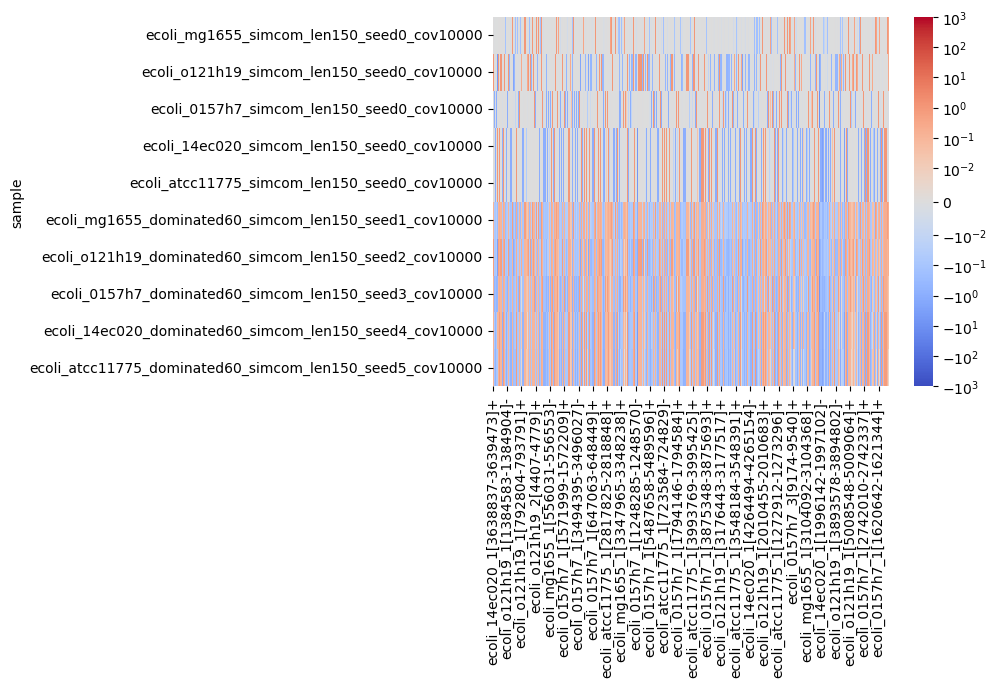

In [43]:
x0, y0 = _ref_pred.align(_tool_pred, fill_value=0)
_resid = x0 - y0
sns.heatmap(
    _resid.T.sample(min(1000, len(_resid)), axis="columns"),
    norm=mpl.colors.SymLogNorm(linthresh=1e-2, vmin=-1000, vmax=1000),
    cmap="coolwarm",
)

In [44]:
# error_result = {}
estimate_result = {}

tool_match_weight_list = [
    (
        "expect",
        match_ref.assign(key=lambda x: x.genome),
        known_rabund
    ),
    (
        "strainzip",
        match_strainzip.assign(key=lambda x: x.vertex),
        strainzip_normalized_depth,
    ),
    (
        "megahit",
        match_megahit.assign(key=lambda x: x.vertex),
        megahit_normalized_depth,
    ),
]


with tqdm(total=len(tool_match_weight_list) * len(thresh_list)) as pbar:
    for thresh_name, _min_identity, _min_coverage in thresh_list:
        _selector = lambda x: (x.identity >= _min_identity) & (
            x.qcoverage >= _min_coverage
        )

        if match_ref[_selector].empty:
            print("No reference sequences match the selector.")
            continue

        # _ref_pred = predict_depth_from_match_and_weight2(
        #     match=match_ref.assign(key=lambda x: x.genome),
        #     weight=known_rabund,
        #     selector=_selector,
        # )
        # estimate_result[('expected', thresh_name, _min_identity, _min_coverage)] = _ref_pred.rename_axis('bench')

        for tool_name, match, weight in tool_match_weight_list:
            _tool_pred = predict_depth_from_match_and_weight2(
                match=match,
                weight=weight,
                selector=_selector,
            )

            estimate_result[(tool_name, thresh_name)] = _tool_pred.rename_axis(index='bench', columns='sample')
            pbar.update()
            
#             x0, y0 = _ref_pred.align(_tool_pred, fill_value=0)
#             d0 = pd.DataFrame(
#                 dict(
#                     expected=x0.rename_axis(index="bench").stack().values,
#                     estimated=y0.rename_axis(index="bench").stack().values,
#                 ),
#                 index=x0.rename_axis(index="bench").stack().index,
#             ).assign(
#                 abs_resid=lambda x: np.abs(x.estimated - x.expected),
#                 sqr_resid=lambda x: np.square(x.estimated - x.expected),
#                 sqr_expect=lambda x: np.square(x.expected),
#             )

#             error_result[(thresh_name, min_coverage, min_identity, tool_name)] = (
#                 pd.DataFrame(
#                     dict(
#                         mean_abs_residual_bench_depth=(
#                             d0.abs_resid.unstack("sample")
#                             .groupby(bench_to_genome)
#                             .mean()
#                             .stack()
#                         ),
#                         mean_square_residual_bench_depth=(
#                             d0.sqr_resid.unstack("sample")
#                             .groupby(bench_to_genome)
#                             .mean()
#                             .stack()
#                         ),
#                         mean_expected_bench_depth=(
#                             d0.expected.unstack("sample")
#                             .groupby(bench_to_genome)
#                             .mean()
#                             .stack()
#                         ),
#                         mean_square_expected_bench_depth=(
#                             d0.sqr_expect.unstack("sample")
#                             .groupby(bench_to_genome)
#                             .mean()
#                             .stack()
#                         ),
#                     )
#                 )
#             )
#             pbar.update()

estimate_result = pd.concat(
    estimate_result, names=["tool", "thresh"]
).stack().to_xarray().fillna(0)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:03<00:00,  4.21it/s]


<Axes: xlabel='None-thresh', ylabel='tool-sample'>

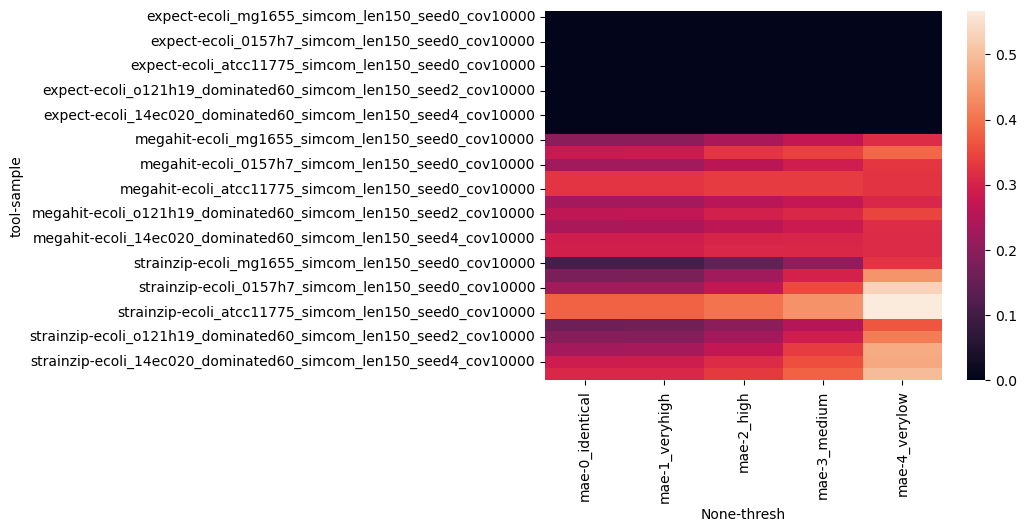

In [45]:
error_result = estimate_result - estimate_result.sel(tool='expect')

d = error_result.pipe(abs).mean("bench").to_dataframe(name='mae')
sns.heatmap(d.unstack('thresh'))

In [46]:
_bench_depth_total = estimate_result.transpose('tool', 'thresh', 'sample', 'bench') * benchmark_sequence_length.rename_axis('bench').to_xarray()
_bench_depth_true = _bench_depth_total.sel(tool='expect')
_bench_depth_error = _bench_depth_total.sel(tool=['megahit', 'strainzip']) - _bench_depth_true

In [47]:
_bench_depth_abs_error = _bench_depth_error.pipe(np.abs)
_bench_to_genome_operator = bench_to_genome.rename_axis('bench').reset_index().assign(val=1).set_index(['bench', 'genome']).val.to_xarray().fillna(0)
_per_genome_bench_depth_abs_error = _bench_depth_abs_error @ _bench_to_genome_operator
_per_genome_bench_depth_total = _bench_depth_true @ _bench_to_genome_operator

_per_genome_bench_depth_normalized_absolute_error = _per_genome_bench_depth_abs_error.sum("sample") / _per_genome_bench_depth_total.sum("sample")

<Axes: xlabel='thresh', ylabel='tool-genome'>

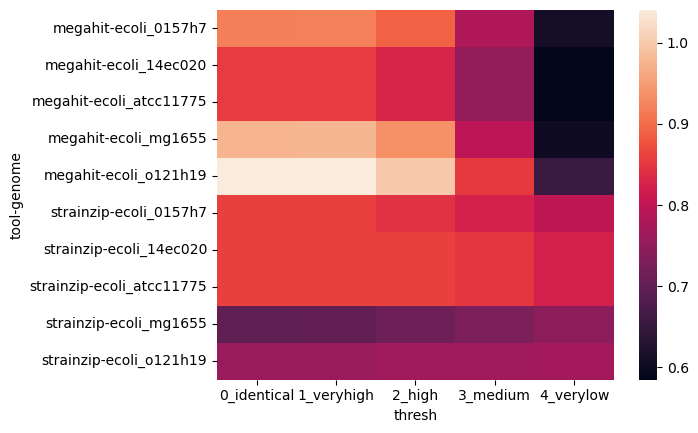

In [48]:
d = _per_genome_bench_depth_normalized_absolute_error.to_series().unstack('thresh')
sns.heatmap(d)

In [77]:
# WORKHERE

thresh = '0_identical'

_mean_rabund = known_rabund.loc[mgen_group.index].mean().rename(lambda x: x.replace('-', '_'))

d0 = _per_genome_bench_depth_normalized_absolute_error.sel(thresh=thresh).to_series().unstack('tool').rename_axis(index='genome_id').rename(lambda x: x.replace('-', '_')).assign(mean_rabund=_mean_rabund)

d0.to_csv('fig/normalized_absolute_error_id100_sim2.tsv', sep='\t')

/tmp/bsmith/ipykernel_1837336/3453142341.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  ax.scatter(d.megahit, d.strainzip, color='k', norm=mpl.colors.PowerNorm(1/3), s=5)


Text(0.5, 1.0, 'Normalized Error')

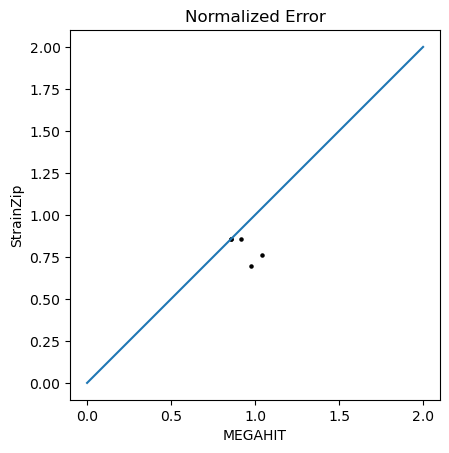

In [74]:
# c = _per_genome_bench_depth_total.sum('sample').sel(thresh=thresh)

d = d0

fig, ax = plt.subplots()
ax.scatter(d.megahit, d.strainzip, color='k', norm=mpl.colors.PowerNorm(1/3), s=5)
# ax.scatter(d.loc[genome_id_list].megahit, d.loc[genome_id_list].strainzip, color='tab:orange', norm=mpl.colors.PowerNorm(1/3))

ax.plot([0, 2], [0, 2])
ax.set_aspect(1)
plt.xlabel('MEGAHIT')
plt.ylabel('StrainZip')
plt.title('Normalized Error')

/tmp/bsmith/ipykernel_1837336/3538799403.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  ax.scatter(d.megahit, d.strainzip, color='tab:purple', norm=mpl.colors.PowerNorm(1/3))


Text(0.5, 1.0, 'Normalized Error')

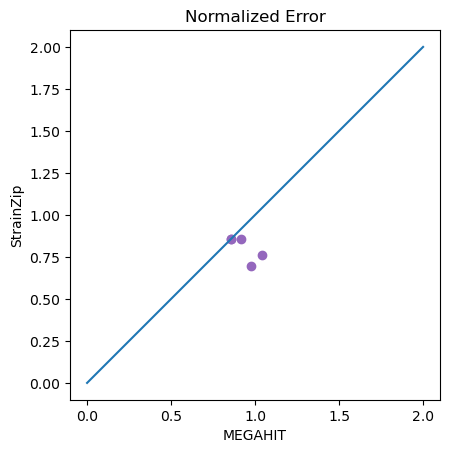

In [49]:
thresh = '0_identical'

d = _per_genome_bench_depth_normalized_absolute_error.sel(thresh=thresh).to_series().unstack('tool')
c = _per_genome_bench_depth_total.sum('sample').sel(thresh=thresh)


fig, ax = plt.subplots()
ax.scatter(d.megahit, d.strainzip, color='tab:purple', norm=mpl.colors.PowerNorm(1/3))
ax.plot([0, 2], [0, 2])
ax.set_aspect(1)
plt.xlabel('MEGAHIT')
plt.ylabel('StrainZip')
plt.title('Normalized Error')

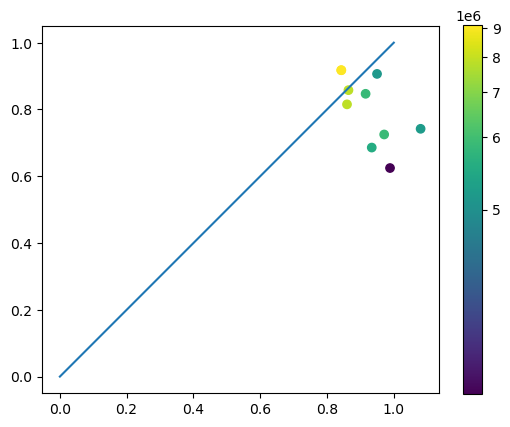

In [50]:
_per_genome_bench_depth_normalized_absolute_error2 = _per_genome_bench_depth_abs_error.sum("genome") / _per_genome_bench_depth_total.sum("genome")

thresh = '0_identical'

d = _per_genome_bench_depth_normalized_absolute_error2.sel(thresh=thresh).to_series().unstack('tool')
c = _per_genome_bench_depth_total.sum('genome').sel(thresh=thresh)


fig, ax = plt.subplots()
_mappable = ax.scatter(d.megahit, d.strainzip, c=c, norm=mpl.colors.PowerNorm(1/3))
fig.colorbar(_mappable)
ax.plot([0, 1], [0, 1])
ax.set_aspect(1)

megahit SignificanceResult(statistic=0.23369724832127373, pvalue=0.0) PearsonRResult(statistic=0.25813180928235313, pvalue=0.0)
strainzip SignificanceResult(statistic=0.4370174294403865, pvalue=0.0) PearsonRResult(statistic=0.6871789521703868, pvalue=0.0)


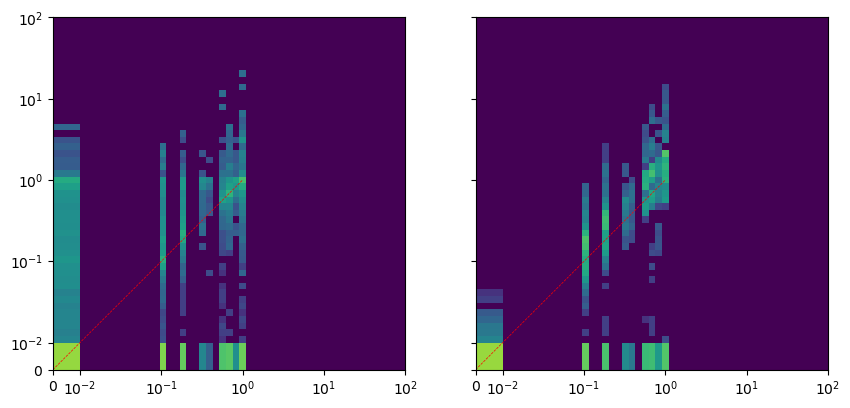

In [51]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 5))


thresh = '0_identical'

d = estimate_result
x = d.sel(tool='expect', thresh=thresh).to_series()



bins = [0] + list(np.logspace(-2, 2))


for ax, tool in zip(axs, ['megahit', 'strainzip']):
    y = d.sel(tool=tool, thresh=thresh).to_series()
    print(tool, sp.stats.spearmanr(x, y), sp.stats.pearsonr(x, y))
    ax.hist2d(x, y, bins=bins, norm=mpl.colors.SymLogNorm(1, vmin=1e-1, vmax=1e6))
    ax.set_xscale('symlog', linthresh=1e-2, linscale=0.3)
    ax.set_yscale('symlog', linthresh=1e-2, linscale=0.3)
    ax.set_aspect(1)
    ax.plot([0, 1], [0, 1], color='r', linestyle='--', lw=0.5)

# QUAST

In [52]:
genome_coverage = []

for tool, stem in [
    ("megahit", "megahit-full-k111"),
    (
        "strainzip",
        f"ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0",  # .contigs-d0",
    ),
]:
    for ident_string in ["10000", "9990", "9950", "9900", "9800"]:
        d = pd.read_table(
            f"data/group/{group}/r.proc.{stem}.quast-{group}-i{ident_string}.d/summary/TSV/Genome_fraction.tsv",
            na_values=["-", ""],
        ).fillna(0)
        d.columns = ["genome_id", "genome_percent"]
        d = d.assign(
            min_identity=int(ident_string) / 10000,
            genome_fraction=lambda x: x.genome_percent / 100,
            tool=tool,
            # sim_depth=int(cov_string) / 100,
        )
        genome_coverage.append(d)

genome_coverage = pd.concat(genome_coverage).set_index(['genome_id', 'tool', 'min_identity']).genome_fraction
genome_coverage.unstack(['genome_id', 'tool']).sort_index(axis=1)

genome_id    ecoli_0157h7           ecoli_14ec020           ecoli_atcc11775  \
tool              megahit strainzip       megahit strainzip         megahit   
min_identity                                                                  
0.980             0.83370   0.98878       0.90034   0.99593         0.90034   
0.990             0.67887   0.98754       0.75798   0.99551         0.75798   
0.995             0.45415   0.98444       0.54806   0.99403         0.54806   
0.999             0.30064   0.96877       0.40209   0.98650         0.40209   
1.000             0.25519   0.94364       0.35348   0.98122         0.35348   

genome_id              ecoli_mg1655           ecoli_o121h19            
tool         strainzip      megahit strainzip       megahit strainzip  
min_identity                                                           
0.980          0.99593      0.86240   0.99558       0.82744   0.98214  
0.990          0.99551      0.69121   0.99526       0.67954   0.98176  
0.995          0.99403      0.42303   0.99391       0.43937   0.97843  
0.999          0.98650      0.23061   0.98874       0.26414   0.95949  
1.000          0.98122      0.20291   0.98350       0.22931   0.94482

In [67]:
# WORKHERE: Add sequencing depth information for each genome and size the points based on that.

min_identity = 1.0

_mean_rabund = known_rabund.loc[mgen_group.index].mean().rename(lambda x: x.replace('-', '_'))
d0 = genome_coverage.xs(min_identity, level='min_identity').unstack().assign(mean_rabund=_mean_rabund)

d0.to_csv('fig/quast_genome_coverage_id100_sim2.tsv', sep='\t')

0.0 -0.68845


Text(0.5, 1.0, 'Un-covered Genome Length')

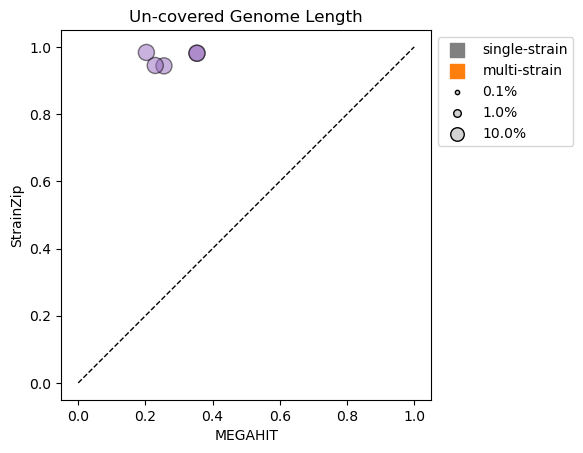

In [69]:
def _rabund_to_size(x):
    return np.sqrt(x) * 300

d = d0.assign(s=d0.mean_rabund.pipe(_rabund_to_size))

x = d['megahit']
y = d['strainzip']

print((y < x).mean(), (x - y).median())


fig, ax = plt.subplots()
ax.scatter('megahit', 'strainzip', data=d, color='tab:purple', edgecolor='k', s='s', alpha=0.5, label='__nolegend__')
ax.plot([0, 1], [0, 1], lw=1, linestyle='--', color='k')
ax.set_aspect(1)
ax.set_xlabel('MEGAHIT')
ax.set_ylabel('StrainZip')

ax.scatter([], [], color='grey', marker='s', label='single-strain', s=100)
ax.scatter([], [], color='tab:orange', marker='s', label='multi-strain', s=100)
for _rabund in [0.001, 0.01, 0.1]:
    ax.scatter([], [], color='lightgrey', edgecolor='k', s=_rabund_to_size(_rabund), label=f'{_rabund:.01%}')
ax.legend(bbox_to_anchor=(1, 1))
ax.set_title('Un-covered Genome Length')

1.0 0.68845


Text(0, 0.5, 'StrainZip')

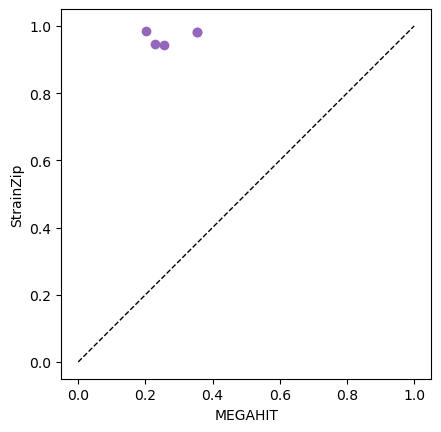

In [53]:
min_identity = 1.0
d = genome_coverage.to_xarray().sel(min_identity=min_identity)

x = d.sel(tool='megahit')
y = d.sel(tool='strainzip')

print((y > x).mean().values, (y - x).median().values)

plt.scatter(x, y, color='tab:purple')
plt.plot([0, 1], [0, 1], lw=1, linestyle='--', color='k')
plt.gca().set_aspect(1)
plt.xlabel('MEGAHIT')
plt.ylabel('StrainZip')

In [54]:
genome_nga50 = []

for tool, stem in [
    ("megahit", "megahit-full-k111"),
    (
        "strainzip",
        f"ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0",  # .contigs-d0",
    ),
]:
    for ident_string in ["10000", "9990", "9950", "9900", "9800"]:
        d = pd.read_table(
            f"data/group/{group}/r.proc.{stem}.quast-{group}-i{ident_string}.d/summary/TSV/NGA50.tsv",
            na_values=["-", ""],
        ).fillna(0)
        d.columns = ["genome_id", "nga50"]
        d = d.assign(
            min_identity=int(ident_string) / 10000,
            tool=tool,
            # sim_depth=int(cov_string) / 100,
        )
        genome_nga50.append(d)

genome_nga50 = pd.concat(genome_nga50).set_index(['genome_id', 'tool', 'min_identity']).nga50
genome_nga50.unstack(['genome_id', 'tool']).sort_index(axis=1)

genome_id    ecoli_0157h7           ecoli_14ec020           ecoli_atcc11775  \
tool              megahit strainzip       megahit strainzip         megahit   
min_identity                                                                  
0.980              1806.0   10665.0        2189.0    8275.0          2189.0   
0.990               729.0   10333.0        1229.0    8054.0          1229.0   
0.995                 0.0   10106.0         399.0    7941.0           399.0   
0.999                 0.0    8063.0           0.0    6715.0             0.0   
1.000                 0.0    4806.0           0.0    5867.0             0.0   

genome_id              ecoli_mg1655           ecoli_o121h19            
tool         strainzip      megahit strainzip       megahit strainzip  
min_identity                                                           
0.980           8275.0       1757.0    6313.0        1647.0    7498.0  
0.990           8054.0        720.0    5778.0         732.0    7109.0  
0.995           7941.0          0.0    5175.0           0.0    6590.0  
0.999           6715.0          0.0    4081.0           0.0    5133.0  
1.000           5867.0          0.0    3461.0           0.0    4064.0

1.0 6086.0


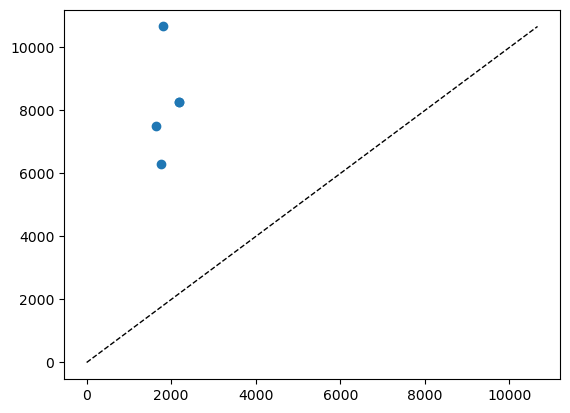

In [55]:
min_identity = 0.98
d = genome_nga50.to_xarray().sel(min_identity=min_identity)

x = d.sel(tool='megahit')
y = d.sel(tool='strainzip')

print((y > x).mean().values, (y - x).median().values)

plt.scatter(x, y)
plt.plot([0, d.max()], [0, d.max()], lw=1, linestyle='--', color='k')

In [56]:
genome_duplication_ratio = []

for tool, stem in [
    ("megahit", "megahit-full-k111"),
    (
        "strainzip",
        f"ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0",  # .contigs-d0",
    ),
]:
    for ident_string in ["10000", "9990", "9950", "9900", "9800"]:
        d = pd.read_table(
            f"data/group/{group}/r.proc.{stem}.quast-{group}-i{ident_string}.d/summary/TSV/Duplication_ratio.tsv",
            na_values=["-", ""],
        ).fillna(0)
        d.columns = ["genome_id", "duplication_ratio"]
        d = d.assign(
            min_identity=int(ident_string) / 10000,
            tool=tool,
            # sim_depth=int(cov_string) / 100,
        )
        genome_duplication_ratio.append(d)

genome_duplication_ratio = pd.concat(genome_duplication_ratio).set_index(['genome_id', 'tool', 'min_identity']).duplication_ratio
genome_duplication_ratio.unstack(['genome_id', 'tool']).sort_index(axis=1)

genome_id    ecoli_0157h7           ecoli_14ec020           ecoli_atcc11775  \
tool              megahit strainzip       megahit strainzip         megahit   
min_identity                                                                  
0.980               1.228     4.881         1.196     4.194           1.196   
0.990               1.148     4.385         1.131     3.799           1.131   
0.995               1.078     3.310         1.076     3.060           1.076   
0.999               1.054     2.546         1.053     2.463           1.053   
1.000               1.060     2.208         1.057     2.220           1.057   

genome_id              ecoli_mg1655           ecoli_o121h19            
tool         strainzip      megahit strainzip       megahit strainzip  
min_identity                                                           
0.980            4.194        1.258     5.482         1.234     5.224  
0.990            3.799        1.166     4.852         1.158     4.691  
0.995            3.060        1.095     3.475         1.085     3.423  
0.999            2.463        1.069     2.475         1.062     2.498  
1.000            2.220        1.075     2.244         1.068     2.244

In [57]:
genome_num_misassemblies = []

for tool, stem in [
    ("megahit", "megahit-full-k111"),
    (
        "strainzip",
        f"ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0",  # .contigs-d0",
    ),
]:
    for ident_string in ["10000", "9990", "9950", "9900", "9800"]:
        d = pd.read_table(
            f"data/group/{group}/r.proc.{stem}.quast-{group}-i{ident_string}.d/summary/TSV/num_misassemblies.tsv",
            na_values=["-", ""],
        ).fillna(0)
        d.columns = ["genome_id", "num_misassemblies"]
        d = d.assign(
            min_identity=int(ident_string) / 10000,
            tool=tool,
            # sim_depth=int(cov_string) / 100,
        )
        genome_num_misassemblies.append(d)

genome_num_misassemblies = pd.concat(genome_num_misassemblies).set_index(['genome_id', 'tool', 'min_identity']).num_misassemblies
genome_num_misassemblies.unstack(['genome_id', 'tool']).sort_index(axis=1)

genome_id    ecoli_0157h7           ecoli_14ec020           ecoli_atcc11775  \
tool              megahit strainzip       megahit strainzip         megahit   
min_identity                                                                  
0.980                  20       123             5        39               5   
0.990                  11        75             3        33               3   
0.995                  10        54             2        20               2   
0.999                   7        15             1        11               1   
1.000                   6        13             1         6               1   

genome_id              ecoli_mg1655           ecoli_o121h19            
tool         strainzip      megahit strainzip       megahit strainzip  
min_identity                                                           
0.980               39            8        46            18       163  
0.990               33            4        26            14       111  
0.995               20            1        16             7        85  
0.999               11            1         5             5        30  
1.000                6            0         3             3        20

# Fraction of Reads Mapping to Erroneous Sequences

### MEGAHIT

In [58]:
megahit_sequence_length = pd.read_table(
    f"data/group/{group}/r.proc.megahit-full-k111.nlength.tsv",
    names=["gene", "nlength"],
    index_col="gene",
).nlength
benchmark_sequence_length

gene
ecoli_mg1655_1[336-2799]+            2463
ecoli_mg1655_1[2800-3733]+            933
ecoli_mg1655_1[3733-5020]+           1287
ecoli_mg1655_1[5233-5530]+            297
ecoli_mg1655_1[5682-6459]-            777
                                     ... 
ecoli_atcc11775_3[159648-160134]-     486
ecoli_atcc11775_3[160123-161224]-    1101
ecoli_atcc11775_3[162080-163274]-    1194
ecoli_atcc11775_3[164496-165402]-     906
ecoli_atcc11775_3[165394-165733]-     339
Name: nlength, Length: 24752, dtype: int64

In [59]:
megahit_to_ref = (
    pd.read_table(
        f"data/group/{group}/r.proc.megahit-full-k111.all_refs-blastn.tsv",
        names=blastn_columns,
    )
    .join(megahit_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        vertex=lambda x: x.sseqid,  # Equivalent to the "genome" field for the ref_match table. I'll join depths based on this.
    )
)

megahit_to_ref  # [lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)]

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,vertex
0,k111_13867,ecoli_0157h7_1,98.954,5163,53,1,1,5162,4487527,4482365,0.000000e+00,9234.0,5162,0.98954,1.000194,0,4487526,5162,4482365,ecoli_0157h7_1
1,k111_13867,ecoli_0157h7_1,89.744,117,12,0,246,362,4276768,4276652,5.760000e-35,150.0,5162,0.89744,0.022666,245,4276767,362,4276652,ecoli_0157h7_1
2,k111_13867,ecoli_0157h7_1,88.430,121,12,2,243,362,691887,691768,2.680000e-33,145.0,5162,0.88430,0.023441,242,691886,362,691768,ecoli_0157h7_1
3,k111_13867,ecoli_0157h7_1,87.805,123,14,1,240,362,495339,495218,9.650000e-33,143.0,5162,0.87805,0.023828,239,495338,362,495218,ecoli_0157h7_1
4,k111_13867,ecoli_0157h7_1,88.235,119,12,2,243,361,3668535,3668419,3.470000e-32,141.0,5162,0.88235,0.023053,242,3668534,361,3668419,ecoli_0157h7_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169008,k111_4823,ecoli_atcc11775_1,100.000,823,0,0,1,823,1393550,1392728,0.000000e+00,1520.0,823,1.00000,1.000000,0,1393549,823,1392728,ecoli_atcc11775_1
169009,k111_4823,ecoli_14ec020_1,100.000,823,0,0,1,823,1393550,1392728,0.000000e+00,1520.0,823,1.00000,1.000000,0,1393549,823,1392728,ecoli_14ec020_1
169010,k111_4823,ecoli_mg1655_1,96.355,823,30,0,1,823,2593787,2594609,0.000000e+00,1354.0,823,0.96355,1.000000,0,2593786,823,2594609,ecoli_mg1655_1
169011,k111_4823,ecoli_o121h19_1,95.869,823,34,0,1,823,1462084,1461262,0.000000e+00,1332.0,823,0.95869,1.000000,0,1462083,823,1461262,ecoli_o121h19_1


In [60]:
megahit_aligned_bases = (megahit_contig_depth.T * megahit_sequence_length).sum(1)
megahit_missaligned_bases = (
    megahit_contig_depth.T.drop(
        columns=megahit_to_ref[
            lambda x: (x.identity >= 0.99) & (x.qcoverage >= coverage_thresh)
        ].qseqid.unique(),
        errors="ignore",
    )
    * megahit_sequence_length
).sum(1)
megahit_well_aligned_frac = 1 - (megahit_missaligned_bases / megahit_aligned_bases)
megahit_well_aligned_frac

sample
ecoli_0157h7_dominated60_simcom_len150_seed3_cov10000       0.833141
ecoli_0157h7_simcom_len150_seed0_cov10000                   0.821553
ecoli_14ec020_dominated60_simcom_len150_seed4_cov10000      0.853289
ecoli_14ec020_simcom_len150_seed0_cov10000                  0.860537
ecoli_atcc11775_dominated60_simcom_len150_seed5_cov10000    0.853405
ecoli_atcc11775_simcom_len150_seed0_cov10000                0.860537
ecoli_mg1655_dominated60_simcom_len150_seed1_cov10000       0.846579
ecoli_mg1655_simcom_len150_seed0_cov10000                   0.847575
ecoli_o121h19_dominated60_simcom_len150_seed2_cov10000      0.843069
ecoli_o121h19_simcom_len150_seed0_cov10000                  0.841201
dtype: float64

### StrainZip

In [61]:
strainzip_sequence_length = pd.read_table(
    f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.nlength.tsv",
    names=["gene", "nlength"],
    index_col="gene",
).nlength
strainzip_sequence_length

gene
23218    64227
25517    64227
41657    55135
32675    54042
48972    51704
         ...  
11930      111
1994       111
11521      111
6716       111
11677      111
Name: nlength, Length: 50633, dtype: int64

In [62]:
strainzip_to_ref = (
    pd.read_table(
        f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.all_refs-blastn.tsv",
        names=blastn_columns,
    )
    .join(strainzip_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        vertex=lambda x: x.sseqid,  # Equivalent to the "genome" field for the ref_match table. I'll join depths based on this.
    )
)

strainzip_to_ref  # [lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)]

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,vertex
0,23218,ecoli_atcc11775_2,100.000,64227,0,0,1,64227,534,64760,0.000000e+00,118600.0,64227,1.00000,1.000000,0,533,64227,64760,ecoli_atcc11775_2
1,23218,ecoli_atcc11775_2,94.382,534,25,4,6072,6604,3656,4185,0.000000e+00,815.0,64227,0.94382,0.008314,6071,3655,6604,4185,ecoli_atcc11775_2
2,23218,ecoli_atcc11775_2,94.382,534,25,4,3123,3652,6605,7137,0.000000e+00,815.0,64227,0.94382,0.008314,3122,6604,3652,7137,ecoli_atcc11775_2
3,23218,ecoli_atcc11775_2,96.396,222,8,0,4160,4381,3963,4184,6.570000e-99,366.0,64227,0.96396,0.003456,4159,3962,4381,4184,ecoli_atcc11775_2
4,23218,ecoli_atcc11775_2,96.396,222,8,0,3430,3651,4693,4914,6.570000e-99,366.0,64227,0.96396,0.003456,3429,4692,3651,4914,ecoli_atcc11775_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690675,1632,ecoli_atcc11775_1,100.000,125,0,0,1,125,4305713,4305837,4.010000e-61,231.0,125,1.00000,1.000000,0,4305712,125,4305837,ecoli_atcc11775_1
690676,1632,ecoli_14ec020_1,100.000,125,0,0,1,125,4305713,4305837,4.010000e-61,231.0,125,1.00000,1.000000,0,4305712,125,4305837,ecoli_14ec020_1
690677,1632,ecoli_0157h7_1,100.000,125,0,0,1,125,5225209,5225085,4.010000e-61,231.0,125,1.00000,1.000000,0,5225208,125,5225085,ecoli_0157h7_1
690678,1632,ecoli_o121h19_1,100.000,125,0,0,1,125,4816373,4816497,4.010000e-61,231.0,125,1.00000,1.000000,0,4816372,125,4816497,ecoli_o121h19_1


In [63]:
strainzip_aligned_kmers = (vertex_depth.T * strainzip_sequence_length).sum(1)
strainzip_missaligned_kmers = (
    vertex_depth.T.drop(
        columns=strainzip_to_ref[
            lambda x: (x.identity >= 0.99) & (x.qcoverage >= coverage_thresh)
        ].qseqid.unique(),
        errors="ignore",
    )
    * strainzip_sequence_length
).sum(1)
strainzip_well_aligned_frac = 1 - (
    strainzip_missaligned_kmers / strainzip_aligned_kmers
)
strainzip_well_aligned_frac

sample
ecoli_mg1655_simcom_len150_seed0_cov10000                   0.985744
ecoli_o121h19_simcom_len150_seed0_cov10000                  0.958181
ecoli_0157h7_simcom_len150_seed0_cov10000                   0.968027
ecoli_14ec020_simcom_len150_seed0_cov10000                  0.971849
ecoli_atcc11775_simcom_len150_seed0_cov10000                0.971849
ecoli_mg1655_dominated60_simcom_len150_seed1_cov10000       0.975420
ecoli_o121h19_dominated60_simcom_len150_seed2_cov10000      0.962367
ecoli_0157h7_dominated60_simcom_len150_seed3_cov10000       0.966996
ecoli_14ec020_dominated60_simcom_len150_seed4_cov10000      0.969826
ecoli_atcc11775_dominated60_simcom_len150_seed5_cov10000    0.969295
dtype: float64

### Combined

In [64]:
missaligned = []

for tool_name, match, weight, length in [
    (
        "strainzip",
        strainzip_to_ref.assign(key=lambda x: x.vertex),
        vertex_depth.T * strainzip_sequence_length,
        strainzip_sequence_length,
    ),
    (
        "megahit",
        megahit_to_ref.assign(key=lambda x: x.vertex),
        megahit_contig_depth.T * megahit_sequence_length,
        megahit_sequence_length,
    ),
]:
    for thresh_name, _min_identity, _min_coverage in thresh_list:
        _selector = lambda x: (x.identity >= _min_identity) & (
            x.qcoverage >= _min_coverage
        )
        missaligned_weight = (
            weight.drop(
                columns=match[_selector].qseqid.unique(),
                errors="ignore",
            )
        ).sum(1)
        missaligned_length = (
            length.drop(
                match[_selector].qseqid.unique(),
                errors="ignore",
            )
        ).sum()

        for sample in missaligned_weight.index:
            missaligned.append(
                dict(
                    sample=sample,
                    thresh=thresh_name,
                    min_coverage=_min_coverage,
                    min_identity=_min_identity,
                    tool=tool_name,
                    missaligned_weight_frac=missaligned_weight.loc[sample]
                    / weight.loc[sample].sum(),
                    missaligned_length_frac=missaligned_length / length.sum(),
                )
            )

missaligned = pd.DataFrame(missaligned)

Text(0.5, 0, 'min_identity')

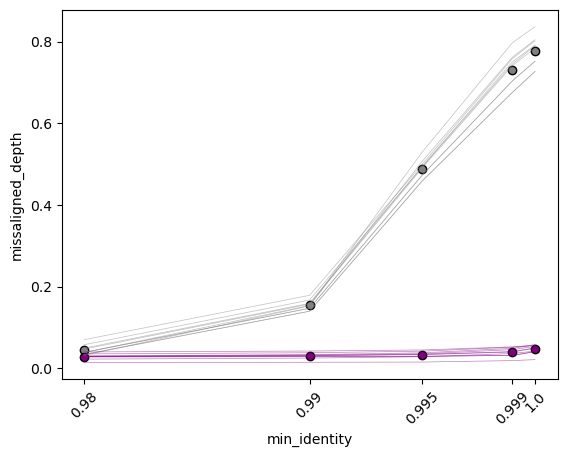

In [65]:
if not missaligned.empty:
    d = (
        missaligned.set_index(["tool", "sample", "min_identity"])
        .sort_index()
        .missaligned_weight_frac.unstack("min_identity")
    )

    for tool in ["megahit", "strainzip"]:
        d2 = d.xs(tool)
        for sample in d2.index:
            d3 = d2.loc[sample]
            plt.plot(
                d3,
                # linestyle=linestyle_palette[tool],
                lw=0.5,
                color={'strainzip': 'purple', 'megahit': 'grey'}[tool],
                # marker="o",
                # markerfacecolor=facecolor_palette[tool],
                alpha=0.5,
            )
        plt.scatter(
            d2.columns,
            d2.mean(0),
            # color="k",
            # lw=3,
            # linestyle=linestyle_palette[tool],
            # markerfacecolor=facecolor_palette[tool],
            marker="o",
            edgecolor='k',
            color={'strainzip': 'purple', 'megahit': 'grey'}[tool],
            label=tool,
        )

plt.xticks(d3.index, d3.index, rotation=45)

plt.ylabel("missaligned_depth")
plt.xlabel("min_identity")
# plt.legend()

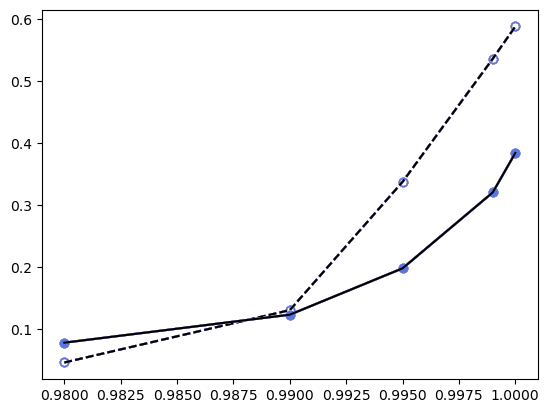

In [66]:
if not missaligned.empty:
    d = (
        missaligned.set_index(["tool", "sample", "min_identity"])
        .sort_index()
        .missaligned_length_frac.unstack("min_identity")
    )

    for tool in ["megahit", "strainzip"]:
        d2 = d.xs(tool)
        for sample in d2.index:
            d3 = d2.loc[sample]
            plt.plot(
                d3,
                linestyle=linestyle_palette[tool],
                c=sample_palette[sample],
                marker="o",
                markerfacecolor=facecolor_palette[tool],
            )
        plt.plot(
            d2.mean(0),
            color="k",
            linestyle=linestyle_palette[tool],
            markerfacecolor=facecolor_palette[tool],
        )